# Variance Ratio Test

This notebook illustrates the Variance Ratio test on crypto data.

Under a random walk, the variance of a `q`-period return should be about `q` times the variance of a 1-period return. The variance ratio is therefore:

$$
VR(q) = \frac{\mathrm{Var}(r_t(q))}{q \cdot \mathrm{Var}(r_t(1))}.
$$

Interpretation:

- $VR(q) \approx 1$: consistent with a random walk
- $VR(q) < 1$: mean reversion
- $VR(q) > 1$: momentum or trending

In [ ]:
import math
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

warnings.filterwarnings("ignore")
pd.set_option("display.float_format", lambda x: f"{x:,.6f}")


In [ ]:
def find_repo_root(start: Path | None = None) -> Path:
    current = Path.cwd() if start is None else start.resolve()
    for candidate in (current, *current.parents):
        if (candidate / "fixtures/crypto/crypto_daily_close.csv").exists():
            return candidate
    raise FileNotFoundError(
        "Missing shared crypto fixture: fixtures/crypto/crypto_daily_close.csv. "
        "Run `python3 scripts/python/download-crypto-fixtures.py --source binance-monthly-archive` "
        "from the repository root."
    )

repo_root = find_repo_root()
fixture_path = repo_root / "fixtures/crypto/crypto_daily_close.csv"

close_matrix = pd.read_csv(fixture_path, parse_dates=["date"]).set_index("date").sort_index()
close_matrix = close_matrix.apply(pd.to_numeric, errors="coerce").dropna(how="all")

symbol = "BTCUSDT"
if symbol not in close_matrix:
    raise ValueError(f"Fixture is missing required symbol: {symbol}")

close = close_matrix[symbol].dropna()
close.name = "close"
log_price = np.log(close)
log_return = log_price.diff().dropna()

log_return.tail()


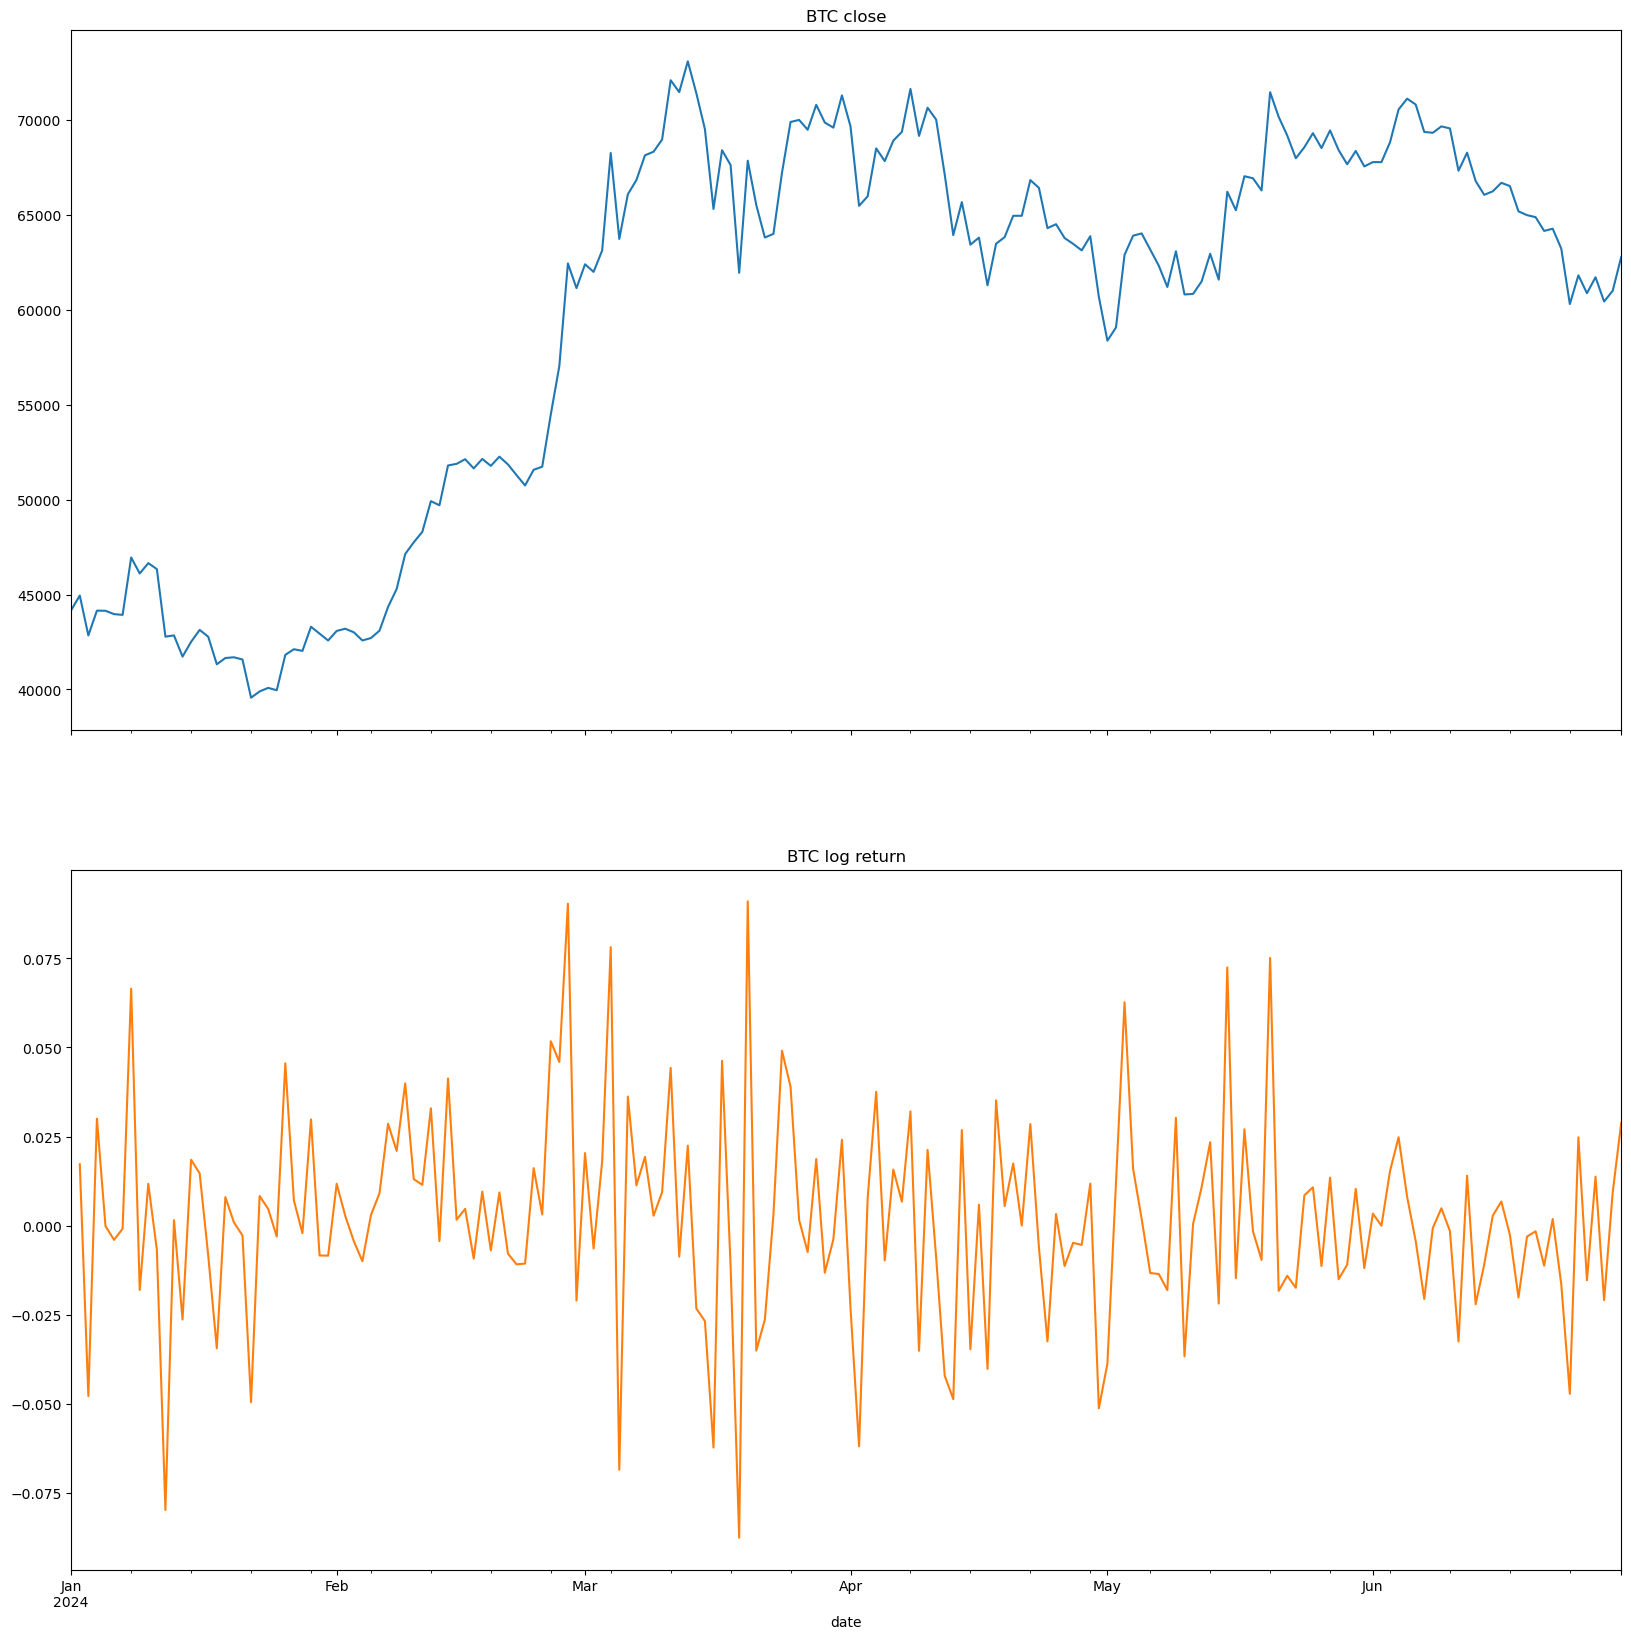

In [4]:
plot_df = pd.concat(
    {
        "BTC close": close,
        "BTC log return": log_return,
    },
    axis=1,
)

plot_df.plot(
    subplots=True,
    figsize=(20, 20),
    title=["BTC close", "BTC log return"],
    layout=(2, 1),
    legend=False,
);

In [5]:
def normal_cdf(x: float) -> float:
    return 0.5 * (1.0 + math.erf(x / math.sqrt(2.0)))


def variance_ratio_test(log_prices: pd.Series, q: int) -> pd.Series:
    """Lo-MacKinlay style variance ratio summary using overlapping returns."""
    y = pd.Series(log_prices).dropna()
    n = len(y)
    mu = (y.iloc[-1] - y.iloc[0]) / (n - 1)

    one_period = y.diff().dropna()
    var_1 = ((one_period - mu) ** 2).sum() / (n - 2)

    q_period = y.diff(q).dropna()
    m = q * (n - q + 1) * (1 - q / n)
    var_q = ((q_period - q * mu) ** 2).sum() / m

    vr = var_q / var_1
    z_stat = (vr - 1.0) / math.sqrt((2.0 * (2.0 * q - 1.0) * (q - 1.0)) / (3.0 * q * n))
    p_value = 2.0 * (1.0 - normal_cdf(abs(z_stat)))

    if vr < 1:
        interpretation = "mean reversion"
    elif vr > 1:
        interpretation = "momentum / trending"
    else:
        interpretation = "random walk"

    return pd.Series(
        {
            "lag": q,
            "variance_ratio": vr,
            "z_stat": z_stat,
            "p_value": p_value,
            "reject_random_walk_5pct": p_value < 0.05,
            "interpretation": interpretation,
        }
    )

In [6]:
lags = [2, 5, 10, 20, 30]

vr_results = pd.DataFrame(
    [variance_ratio_test(log_price, q) for q in lags]
).set_index("lag")

vr_results

,variance_ratio,z_stat,p_value,reject_random_walk_5pct,interpretation
lag,,,,,
2,0.851824,-1.999005,0.045608,True,mean reversion
5,0.906470,-0.575925,0.564666,False,mean reversion
10,0.932278,-0.270592,0.786705,False,mean reversion
20,1.156098,0.423726,0.671766,False,momentum / trending
30,1.302518,0.661864,0.508059,False,momentum / trending


In [7]:
summary_df = vr_results.copy()
summary_df["verdict_5pct"] = np.where(
    summary_df["reject_random_walk_5pct"],
    "reject random walk",
    "fail to reject random walk",
)
summary_df[["variance_ratio", "z_stat", "p_value", "interpretation", "verdict_5pct"]]

,variance_ratio,z_stat,p_value,interpretation,verdict_5pct
lag,,,,,
2,0.851824,-1.999005,0.045608,mean reversion,reject random walk
5,0.906470,-0.575925,0.564666,mean reversion,fail to reject random walk
10,0.932278,-0.270592,0.786705,mean reversion,fail to reject random walk
20,1.156098,0.423726,0.671766,momentum / trending,fail to reject random walk
30,1.302518,0.661864,0.508059,momentum / trending,fail to reject random walk


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

summary_df["variance_ratio"].plot(marker="o", ax=axes[0], color="tab:blue")
axes[0].axhline(1.0, color="black", linestyle="--", linewidth=1, label="random walk")
axes[0].set_title("Variance ratio across horizons")
axes[0].set_xlabel("lag q")
axes[0].set_ylabel("VR(q)")
axes[0].legend()

summary_df["p_value"].plot(kind="bar", ax=axes[1], color=np.where(summary_df["reject_random_walk_5pct"], "tab:red", "tab:gray"))
axes[1].axhline(0.05, color="black", linestyle="--", linewidth=1)
axes[1].set_title("Variance-ratio p-values")
axes[1].set_xlabel("lag q")
axes[1].set_ylabel("p-value")
axes[1].tick_params(axis="x", rotation=0)

plt.tight_layout();


In [ ]:
rolling_window = 90
rolling_vr = pd.DataFrame(
    {
        q: log_price.rolling(rolling_window).apply(
            lambda window, lag=q: variance_ratio_test(pd.Series(window), lag)["variance_ratio"],
            raw=False,
        )
        for q in [5, 10, 20]
    }
).dropna()

fig, ax = plt.subplots(figsize=(12, 5))
rolling_vr.plot(ax=ax, linewidth=2)
ax.axhline(1.0, color="black", linestyle="--", linewidth=1, label="random walk")
ax.set_title(f"Rolling {rolling_window}-day variance ratio")
ax.set_ylabel("VR(q)")
ax.legend(title="lag q")
plt.tight_layout();


## Interpretation

If the variance ratio stays below 1 across multiple lags, the series shows slower diffusion than a random walk, which is consistent with mean reversion. If it stays near 1 and the p-values are large, the data are hard to distinguish from a random walk.